In [1]:
import pandas as pd

# Load the dataset
data = pd.read_excel('student_exam_dataset_200_rows.xlsx')
print(data.head())

   study_hours  attendance group_discussion  previous_test_score  \
0            8         100               No                   51   
1           21          71              Yes                   79   
2           30          77              Yes                   38   
3           16          51              Yes                   70   
4           12          91               No                   65   

  final_exam_pass  
0            Fail  
1            Pass  
2            Pass  
3            Pass  
4            Pass  


1. What is Probability?
- Probability is a measure of how likely an event is to occur. Its value ranges from 0 to 1.
2. Key Probability Terminology?
- Event - An outcome or a set of outcomes of an experiment.
- Sample Space - The set of all possible outcomes of an experiment.
- Random Variable - A variable that takes on different values based on the outcome of a random event.
- Empirical Probability - The probability of an event based on observed data.
- Theoretical Probability - The probability of an event based on mathematical reasoning or models.
- Independent Events - Two events are independent if the occurrence of one does not affect the occurrence of the other.
3. Given three probability example from given dataset?
- Student passes the final exam.
- Student has attendance greater than 80%.
- Student participated in group discussion and passed the exam.



# Types of Events
A. Empirical Probability
- Example:- A randomly selected student passes the final exam. 

In [2]:
total_students = len(data)
passed_students = len(data[data['final_exam_pass'] == 'Pass'])

empirical_prob = passed_students / total_students

print("Total Students:", total_students)
print("Students Passed:", passed_students)
print("Empirical Probability of Passing =", round(empirical_prob, 4))

Total Students: 200
Students Passed: 136
Empirical Probability of Passing = 0.68


B.Theoretical Probability
- Example:- A randomly selected student either passes or fails.

In [3]:
theoretical = 1 / 2
print("Theoretical Probability of Passing =", theoretical)

Theoretical Probability of Passing = 0.5


3. Random Variable & Probability Distribution
- Define a random variable for the event “Number of students passing the final exam” out of 3 randomly selected students.
- Construct its probability distribution table.
- Find the mean and variance of this random variable.


In [4]:
from math import comb
n = 3
p = empirical_prob

print("\nProbability Distribution Table")
print("X\tP(X=x)")

probabilities = []

for x in range(n + 1):
    prob = comb(n, x) * (p ** x) * ((1 - p) ** (n - x))
    probabilities.append(prob)
    print(f"{x}\t{prob:.4f}")
mean = n * p
variance = n * p * (1 - p)

print("\nMean =", round(mean, 4))
print("Variance =", round(variance, 4))


Probability Distribution Table
X	P(X=x)
0	0.0328
1	0.2089
2	0.4439
3	0.3144

Mean = 2.04
Variance = 0.6528


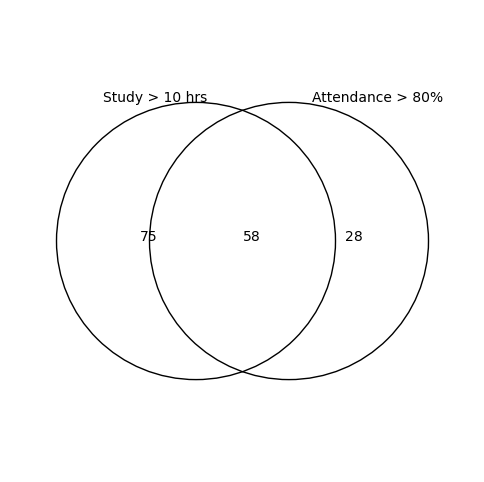

In [10]:
import matplotlib.pyplot as plt


A = data[data["study_hours"] > 10]
B = data[data["attendance"] > 80]

A_count = len(A)
B_count = len(B)
AB_count = len(data[(data["study_hours"] > 10) &
                  (data["attendance"] > 80)])

fig, ax = plt.subplots(figsize=(6,6))

circle1 = plt.Circle((0.4, 0.5), 0.3, fill=False)
circle2 = plt.Circle((0.6, 0.5), 0.3, fill=False)

ax.add_patch(circle1)
ax.add_patch(circle2)

ax.text(0.28, 0.5, f"{A_count - AB_count}")
ax.text(0.50, 0.5, f"{AB_count}")
ax.text(0.72, 0.5, f"{B_count - AB_count}")

ax.text(0.2, 0.8, "Study > 10 hrs")
ax.text(0.65, 0.8, "Attendance > 80%")

plt.axis('off')
plt.show()

5. Contingency Table & Probability Calculations


In [ ]:
table = pd.crosstab(
    data["group_discussion"],
    data["final_exam_pass"]
)

print("Contingency Table:")
print(table)

total = len(data)

joint_count = len(data[
    (data["group_discussion"] == "Yes") &
    (data["final_exam_pass"] == "Pass")
])

joint_prob = joint_count / total

pass_count = len(data[data["final_exam_pass"] == "Pass"])
marginal_prob = pass_count / total

yes_count = len(data[data["group_discussion"] == "Yes"])

conditional_prob = joint_count / yes_count

print("\nJoint Probability P(Group Discussion=Yes AND Pass)")
print(round(joint_prob, 4))

print("\nMarginal Probability P(Pass)")
print(round(marginal_prob, 4))

print("\nConditional Probability P(Pass | Group Discussion=Yes)")
print(round(conditional_prob, 4))

Contingency Table:
final_exam_pass   Fail  Pass
group_discussion            
No                  33    44
Yes                 31    92

Joint Probability P(Group Discussion=Yes AND Pass)
0.46

Marginal Probability P(Pass)
0.68

Conditional Probability P(Pass | Group Discussion=Yes)
0.748


# 6. Understanding Relationships


From the contingency table:

P(Pass) = 136 / 200 = 0.68
P(Pass | Group Discussion = Yes) = 91 / 118 = 0.77 (approx.)

This means that overall, 68% of students passed the exam, but among students who participated in group discussions, about 77% passed.

In practical terms, students who participate in group discussions seem to have a higher chance of passing the exam compared to the overall student population. Participation in discussions may help students understand concepts better, clear doubts, and improve their performance.

Let:

A = Student participates in group discussions
B = Student passes the final exam

Since:

P(B)=0.68

and

P(B∣A)=0.77

These values are not equal. Therefore, the probability of passing changes when we know that a student participated in group discussions.

Hence, A and B are Dependent Events.

Also, many students both participated in group discussions and passed the exam (91 students). Therefore, the events can occur together and are not mutually exclusive.

In [12]:

p_pass = len(data[data["final_exam_pass"] == "Pass"]) / len(data)

yes_students = data[data["group_discussion"] == "Yes"]

p_pass_given_yes = (
    len(yes_students[yes_students["final_exam_pass"] == "Pass"])
    / len(yes_students)
)

print("P(Pass) =", round(p_pass, 4))
print("P(Pass | Group Discussion = Yes) =", round(p_pass_given_yes, 4))

if abs(p_pass - p_pass_given_yes) < 0.0001:
    print("\nEvents are Independent")
else:
    print("\nEvents are Dependent")

joint = len(data[
    (data["group_discussion"] == "Yes") &
    (data["final_exam_pass"] == "Pass")
])

if joint == 0:
    print("Events are Mutually Exclusive")
else:
    print("Events are NOT Mutually Exclusive")

P(Pass) = 0.68
P(Pass | Group Discussion = Yes) = 0.748

Events are Dependent
Events are NOT Mutually Exclusive


# 7. Bayes Theorem Application

In [13]:
P_high_given_pass = 0.70
P_high = 0.60
P_pass = 136 / 200

numerator = P_high_given_pass * P_pass

print("Numerator =", numerator)

result = numerator / P_high

print("P(Pass | High Attendance) =", result)
print("Probability =", round(result, 4))
print("Percentage =", round(result * 100, 2), "%")

Numerator = 0.476
P(Pass | High Attendance) = 0.7933333333333333
Probability = 0.7933
Percentage = 79.33 %
